In [115]:
import os, sys, pickle
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

EI_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'eigen-interactions'))
sys.path.insert(0, EI_DIR)
from eigen_steering import EigenMap, PROMOTER_SEQ, RAND_BARCODE
from fast_logo import fast_logo

SEAM_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
FG_DIR = os.path.join(SEAM_ROOT, 'results', 'foregrounds')

with open(os.path.join(SEAM_ROOT, 'libraries', 'hippo_target_library.pkl'), 'rb') as f:
    lib = pickle.load(f)
df = lib['df']

# Build seq -> npz index lookup (npz used dropna(sequence) only)
JOINT_CSV = '/grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/Cell_line_MoCon/Cross-line_analysis/pred_first/joint_data/joint_library_combined.csv'
joint_df = pd.read_csv(JOINT_CSV).dropna(subset=['sequence']).reset_index(drop=True)
seq_to_npz = {s: i for i, s in enumerate(joint_df['sequence'])}

# Load npz once
attr_data = np.load(lib['attr_npz_path'], allow_pickle=False)

In [116]:
# --- Select sequence ---
# condition: 'same-diff', 'diff-diff', 'same-same'
# rank: 0 = most negative EI_1, 1 = 2nd, etc.
CONDITION_FILTER = 'same-diff'
RANK = 2  # 3rd most negative within this condition

subset = df[df['condition'] == CONDITION_FILTER].sort_values('EI_1 var x r').reset_index(drop=True)
print(f"{len(subset)} seqs in '{CONDITION_FILTER}'")
print(subset[['seq_idx', 'EI_1 var x r', 'pred_K562', 'pred_HepG2']].head(10))

row = subset.iloc[RANK]
SEQ_IDX = row['seq_idx']
CONDITION = row['condition']
SEQ = row['sequence']

print(f"\nSelected: seq_idx={SEQ_IDX}, EI_1={row['EI_1 var x r']:.4f}")
print(f"  pred_K562={row['pred_K562']:.3f}, pred_HepG2={row['pred_HepG2']:.3f}")
print(f"  K562_log2FC={row['K562_log2FC']:.3f}, HepG2_log2FC={row['HepG2_log2FC']:.3f}")

353 seqs in 'same-diff'
   seq_idx  EI_1 var x r  pred_K562  pred_HepG2
0    56772     -0.784848  -0.982792    1.836308
1    38571     -0.784601  -0.711974    0.926399
2    53717     -0.753810  -0.418904    1.016396
3    56720     -0.739573  -0.795999    1.861329
4    55788     -0.735543  -0.488176    0.286052
5    49334     -0.728182  -0.592026    0.690473
6    56910     -0.724025  -0.766621    2.011120
7    46756     -0.723678  -0.958071    0.847493
8    42132     -0.723614  -0.575259    1.334094
9    56731     -0.722818  -0.727875    1.150200

Selected: seq_idx=53717, EI_1=-0.7538
  pred_K562=-0.419, pred_HepG2=1.016
  K562_log2FC=0.197, HepG2_log2FC=0.522


In [117]:
# --- TFMoDISco / annotation params ---
WINDOW_SIZE = 10
FLANK = 5
PVAL_THRESH = 0.05
N_NEAREST = 5
TOP_K = 1
MAX_PARALOGS = 1

EigenMap: ['HepG2', 'K562'], models={'HepG2': 'HepG2_twostep_v4_do03', 'K562': 'K562_twostep_v4_do03'}
Loaded 1 sequences, X shape: torch.Size([1, 4, 281])
  HepG2: 58721 genes, median TPM=0.00
  K562: 58721 genes, median TPM=0.00
  TF lookup: 57133 gene symbols across ['HepG2', 'K562']
  HepG2: 4 motif hits (p<0.05)
  K562: 5 motif hits (p<0.05)
Eigendecomposed 1 sequences (enhancer only, 230bp)
annotate_tf_binding(gaussian): 8/9 TF assignments changed across 1 sequences (sigma=0.642)


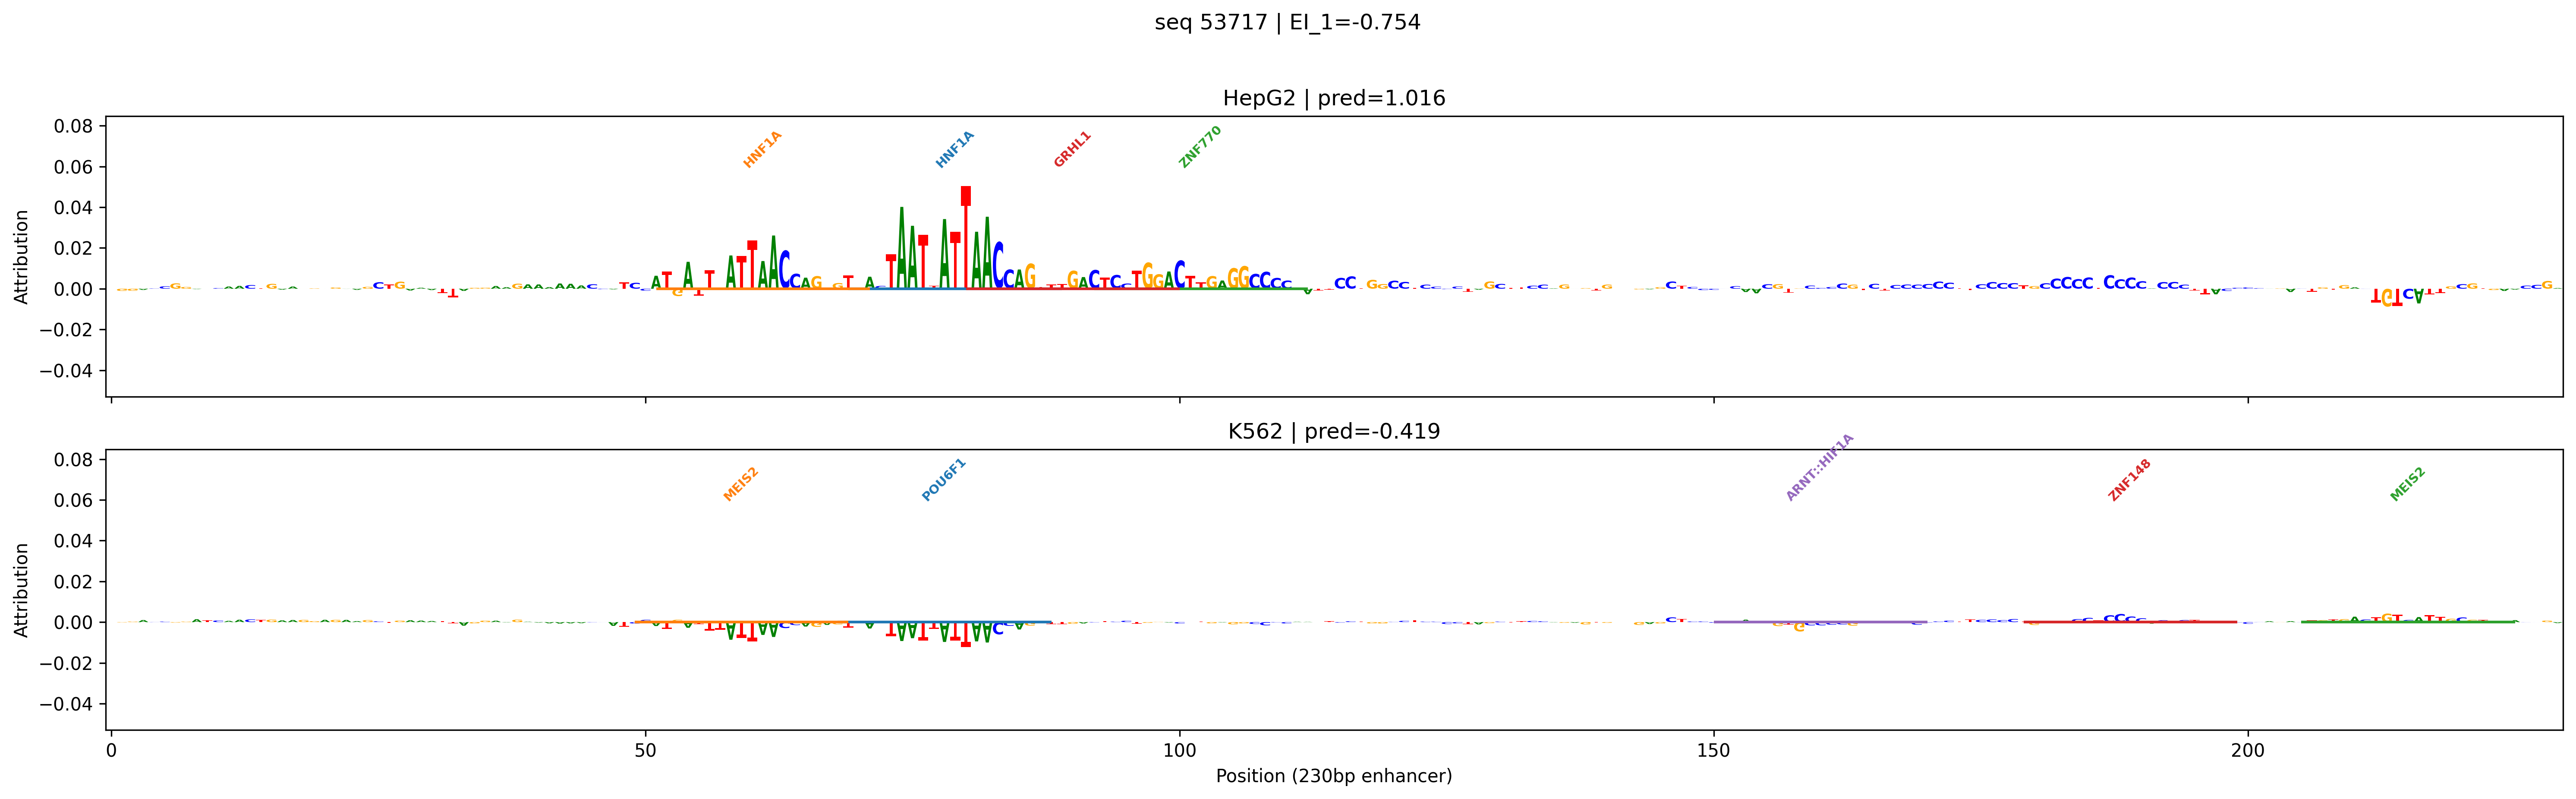

In [118]:
# Load cached attributions + annotate motifs + rank by binding score
import importlib, eigen_steering; importlib.reload(eigen_steering)
from eigen_steering import EigenMap

npz_idx = seq_to_npz[SEQ]

em = EigenMap(cell_types=['HepG2', 'K562'])
em.load_sequences([SEQ])
ohe = em.X.numpy()
for ct in ['HepG2', 'K562']:
    hyp = attr_data[f'attr_{ct}'][npz_idx:npz_idx+1]
    em.attr_hyp[ct] = hyp
    em.attr[ct] = hyp * ohe
    em.importance[ct] = em.attr[ct].sum(axis=1)
    em.predictions[ct] = attr_data[f'predictions_{ct}'][npz_idx:npz_idx+1]

em.load_expression()
em.annotate_motifs(window_size=WINDOW_SIZE, flank=FLANK, pval_thresh=PVAL_THRESH, n_nearest=N_NEAREST)
em.eigendecompose()
em.annotate_tf_binding(method='gaussian')

hits_source = em.motif_hits_ranked

# Plot attribution logos with underline annotations
fig, axes = plt.subplots(2, 1, figsize=(20, 6), sharex=True, dpi=300)
all_vals = np.concatenate([em.attr[ct][0].ravel() for ct in ['HepG2', 'K562']])
yabs = max(abs(all_vals.min()), abs(all_vals.max())) * 1.05

MOTIF_COLORS = plt.cm.tab10.colors

for ci, ct in enumerate(['HepG2', 'K562']):
    fast_logo(em.attr[ct][0, :, :230].T, ax=axes[ci], ylim=(-yabs, yabs))
    axes[ci].set_title(f'{ct} | pred={em.predictions[ct][0]:.3f}')
    axes[ci].set_ylabel('Attribution')

    hits = hits_source[ct][0]
    if hits:
        ylim = axes[ci].get_ylim()
        yrange = ylim[1] - ylim[0]
        axes[ci].set_ylim(ylim[0], ylim[1] + yrange * 0.3)
        for hi, h in enumerate(hits):
            color = MOTIF_COLORS[hi % len(MOTIF_COLORS)]
            axes[ci].plot([h['start'], h['end']], [0, 0],
                          lw=1.5, color=color, solid_capstyle='butt')
            mid = (h['start'] + h['end']) / 2
            axes[ci].annotate(h['tf'], xy=(mid, ylim[1] + yrange * 0.05),
                              fontsize=7, ha='center', va='bottom',
                              rotation=45, color=color, fontweight='bold')

axes[-1].set_xlabel('Position (230bp enhancer)')
plt.suptitle(f'seq {SEQ_IDX} | EI_1={row["EI_1 var x r"]:.3f}', y=1.02)
plt.tight_layout()
plt.show()

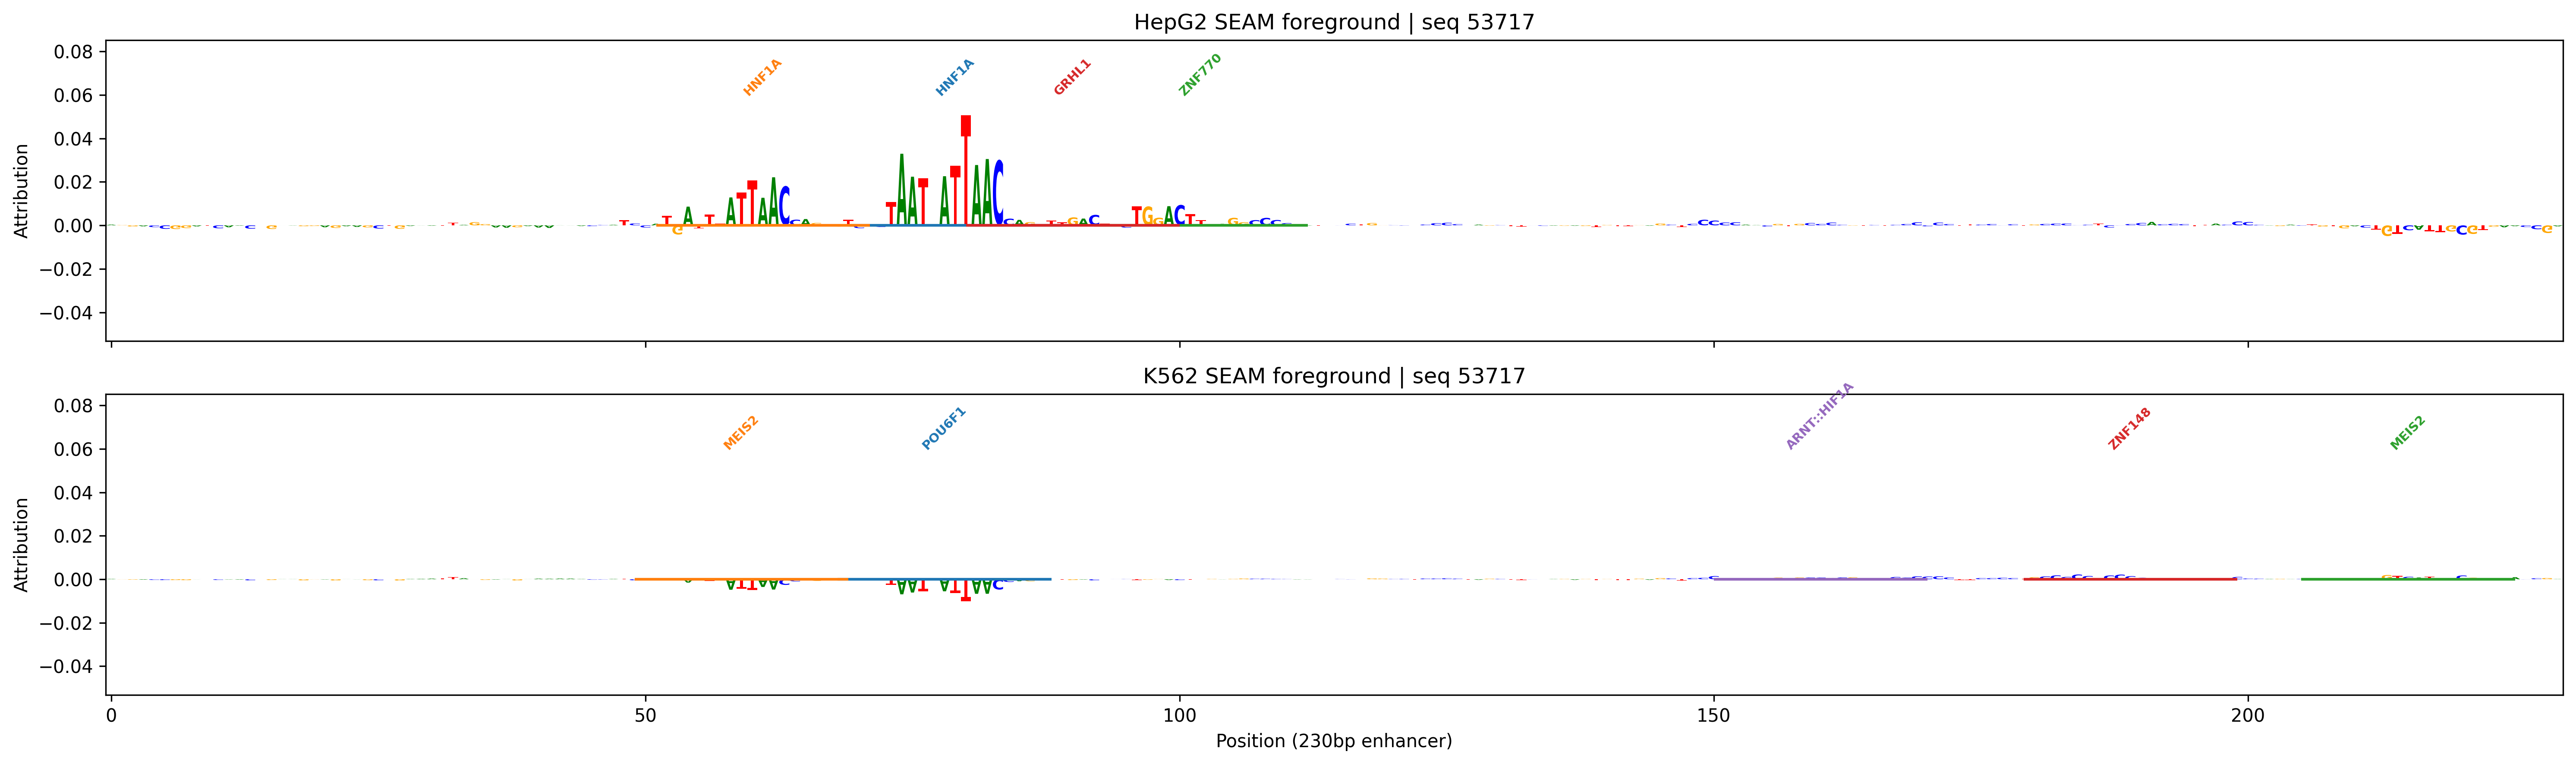

In [119]:
# SEAM foregrounds — one-hot masked to WT base only, with motif annotations
ohe_enh = np.zeros((230, 4), dtype=np.float32)
for i, b in enumerate(SEQ):
    ohe_enh[i, 'ACGT'.index(b)] = 1.0

fig, axes = plt.subplots(2, 1, figsize=(20, 6), sharex=True, dpi=300)
fgs = {ct: np.load(os.path.join(FG_DIR, ct, str(SEQ_IDX), 'foreground_scaled.npy')) * ohe_enh
       for ct in ['HepG2', 'K562']}
yabs = max(abs(v).max() for v in fgs.values()) * 1.05

MOTIF_COLORS = plt.cm.tab10.colors

for ci, ct in enumerate(['HepG2', 'K562']):
    fast_logo(fgs[ct], ax=axes[ci], ylim=(-yabs, yabs))
    axes[ci].set_title(f'{ct} SEAM foreground | seq {SEQ_IDX}')
    axes[ci].set_ylabel('Attribution')

    hits = hits_source[ct][0]
    if hits:
        ylim = axes[ci].get_ylim()
        yrange = ylim[1] - ylim[0]
        axes[ci].set_ylim(ylim[0], ylim[1] + yrange * 0.3)
        for hi, h in enumerate(hits):
            color = MOTIF_COLORS[hi % len(MOTIF_COLORS)]
            axes[ci].plot([h['start'], h['end']], [0, 0],
                          lw=1.5, color=color, solid_capstyle='butt')
            mid = (h['start'] + h['end']) / 2
            axes[ci].annotate(h['tf'], xy=(mid, ylim[1] + yrange * 0.05),
                              fontsize=7, ha='center', va='bottom',
                              rotation=45, color=color, fontweight='bold')

axes[-1].set_xlabel('Position (230bp enhancer)')
plt.tight_layout()
plt.show()

In [120]:
#show all motif hits and their spans
for ct in ['HepG2', 'K562']:
    print(f'\n{ct}:')
    for h in em.motif_hits[ct][0]:
        print(f"  {h['tf']:15s}  {h['start']:3d}-{h['end']:3d}  ({h['end']-h['start']}bp)  pval={h['pval']:.4f}")


HepG2:
  HNF1B             69- 89  (20bp)  pval=0.0001
  PBX2              51- 71  (20bp)  pval=0.0003
  ZFTA              92-112  (20bp)  pval=0.0004
  GRHL1             80-100  (20bp)  pval=0.0006

K562:
  HNF1B             68- 88  (20bp)  pval=0.0001
  PBX2              49- 69  (20bp)  pval=0.0003
  Ahr::Arnt        205-225  (20bp)  pval=0.0005
  SP5              179-199  (20bp)  pval=0.0000
  HIF1A            150-170  (20bp)  pval=0.0003
